## 1. Introduction

**LightGBM (Light Gradient Boosting Machine)** is a high-performance gradient boosting framework developed by Microsoft.
It is designed for **efficient, scalable, and high-accuracy machine learning**, especially for large datasets.

The **LGBMClassifier** is the **classification version** of LightGBM used to solve **supervised learning classification problems** such as:

* Fraud detection
* Customer churn prediction
* Disease classification
* Spam detection

LightGBM belongs to the family of **Gradient Boosting Decision Tree (GBDT)** algorithms.


# 2. Core Idea of LightGBM

LightGBM builds an **ensemble of decision trees sequentially**.

Each new tree is trained to **correct the errors made by the previous trees**.

Mathematically, the model prediction is:

$$
F(x) = \sum_{m=1}^{M} f_m(x)
$$

Where:

* $F(x)$ = Final prediction
* $f_m(x)$ = m-th decision tree
* $M$ = Number of trees

The model **minimizes a loss function** using **gradient descent in function space**.


# 3. Gradient Boosting Concept

LightGBM is based on **Gradient Boosting**.

The training process follows these steps:

1. Start with an initial prediction.
2. Calculate the **loss function**.
3. Compute the **gradient (error)**.
4. Train a new decision tree to predict the gradient.
5. Update the model.
6. Repeat until convergence.

Loss function example for classification:

* Binary Log Loss
* Cross-Entropy Loss


# 4. Key Innovations in LightGBM

LightGBM introduces several techniques that make it **much faster and more efficient** than traditional GBDT implementations.



## 4.1 Histogram-Based Learning

Instead of evaluating every possible split, LightGBM:

* Converts continuous features into **histogram bins**.

Example:

```
Age → bins
20-30
30-40
40-50
```

Benefits:

* Faster training
* Lower memory usage

## 4.2 Leaf-wise Tree Growth (Best-first)

Traditional boosting methods grow trees **level-wise**.

Example:

```
Level-wise:
        root
      /      \
   node     node
```

LightGBM grows trees **leaf-wise**.

Example:

```
Leaf-wise:
      root
     /
  deeper node
```

Advantages:

* Faster loss reduction
* Higher accuracy

Disadvantage:

* Risk of **overfitting**

To control this, LightGBM uses:

* `max_depth`
* `num_leaves`



## 4.3 Gradient-based One-Side Sampling (GOSS)

LightGBM improves efficiency by:

* Keeping **samples with large gradients**
* Randomly sampling **small-gradient samples**

This allows the model to:

* Focus on **hard examples**
* Reduce computation


## 4.4 Exclusive Feature Bundling (EFB)

High-dimensional sparse features are **combined into bundles**.

Example:

```
Feature1 = 0 1 0
Feature2 = 1 0 0
```

These features are **mutually exclusive**, so they can be merged.

Benefits:

* Faster training
* Reduced dimensionality


# 5. Objective Function

LightGBM minimizes:

$$
L = \sum_{i=1}^{n} l(y_i, \hat{y_i}) + \sum_{k} \Omega(f_k)
$$

Where:

* $l(y_i, \hat{y_i})$ = loss function
* $\Omega(f_k)$ = regularization term
* $f_k$ = tree function

Regularization helps prevent **overfitting**.



# 6. Important Hyperparameters

Key parameters in **LGBMClassifier**:

| Parameter         | Description                |
| ----------------- | -------------------------- |
| n_estimators      | Number of boosting trees   |
| learning_rate     | Step size for each tree    |
| num_leaves        | Maximum leaves in one tree |
| max_depth         | Maximum tree depth         |
| min_child_samples | Minimum data per leaf      |
| subsample         | Row sampling               |
| colsample_bytree  | Feature sampling           |


# 7. Advantages of LightGBM

- Very fast training
- Handles large datasets
- High predictive accuracy
- Low memory usage
- Supports parallel learning
- Works well with categorical features


# 8. Limitations

- Can overfit on small datasets
- Sensitive to hyperparameters
- Leaf-wise growth may create deep trees


# 9. Comparison with Other Boosting Models

| Model    | Key Idea                      |
| -------- | ----------------------------- |
| XGBoost  | Level-wise tree growth        |
| LightGBM | Leaf-wise growth (faster)     |
| CatBoost | Best for categorical features |


# 10. Typical Use Cases

LightGBM is widely used in:

* Credit risk modeling
* Recommendation systems
* Fraud detection
* Medical diagnosis
* Customer behavior prediction

It is also very popular in **machine learning competitions such as Kaggle.**


**Importing Libraries**

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve
)

# Dataset
from sklearn.datasets import load_breast_cancer

# Model
from lightgbm import LGBMClassifier

# Explainability
import shap

# Feature importance
from sklearn.inspection import permutation_importance

# Save model
import joblib

import warnings
warnings.filterwarnings("ignore")

**Load dataset**

In [2]:
data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target")

In [3]:
df = pd.concat([X, y], axis=1)

In [4]:
print("Dataset shape:", df.shape)

Dataset shape: (569, 31)


In [5]:
display(df.head())

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [6]:
print(data.DESCR[:1000])

.. _breast_cancer_dataset:

Breast cancer wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 569

:Number of Attributes: 30 numeric, predictive attributes and the class

:Attribute Information:
    - radius (mean of distances from center to points on the perimeter)
    - texture (standard deviation of gray-scale values)
    - perimeter
    - area
    - smoothness (local variation in radius lengths)
    - compactness (perimeter^2 / area - 1.0)
    - concavity (severity of concave portions of the contour)
    - concave points (number of concave portions of the contour)
    - symmetry
    - fractal dimension ("coastline approximation" - 1)

    The mean, standard error, and "worst" or largest (mean of the three
    worst/largest values) of these features were computed for each image,
    resulting in 30 features.  For instance, field 0 is Mean Radius, field
    10 is Radius SE, field 20 is Worst Radius.

    - 

**Exploratory Data Analysis (EDA)**

In [7]:
print("Data types:\n", df.dtypes)

Data types:
 mean radius                float64
mean texture               float64
mean perimeter             float64
mean area                  float64
mean smoothness            float64
mean compactness           float64
mean concavity             float64
mean concave points        float64
mean symmetry              float64
mean fractal dimension     float64
radius error               float64
texture error              float64
perimeter error            float64
area error                 float64
smoothness error           float64
compactness error          float64
concavity error            float64
concave points error       float64
symmetry error             float64
fractal dimension error    float64
worst radius               float64
worst texture              float64
worst perimeter            float64
worst area                 float64
worst smoothness           float64
worst compactness          float64
worst concavity            float64
worst concave points       float64
worst s

In [8]:
print("\nMissing values:\n", df.isnull().sum())


Missing values:
 mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
target                     0
dtype: int64


In [9]:
print("\nStatistical summary:\n", df.describe())


Statistical summary:
        mean radius  mean texture  mean perimeter    mean area  \
count   569.000000    569.000000      569.000000   569.000000   
mean     14.127292     19.289649       91.969033   654.889104   
std       3.524049      4.301036       24.298981   351.914129   
min       6.981000      9.710000       43.790000   143.500000   
25%      11.700000     16.170000       75.170000   420.300000   
50%      13.370000     18.840000       86.240000   551.100000   
75%      15.780000     21.800000      104.100000   782.700000   
max      28.110000     39.280000      188.500000  2501.000000   

       mean smoothness  mean compactness  mean concavity  mean concave points  \
count       569.000000        569.000000      569.000000           569.000000   
mean          0.096360          0.104341        0.088799             0.048919   
std           0.014064          0.052813        0.079720             0.038803   
min           0.052630          0.019380        0.000000           

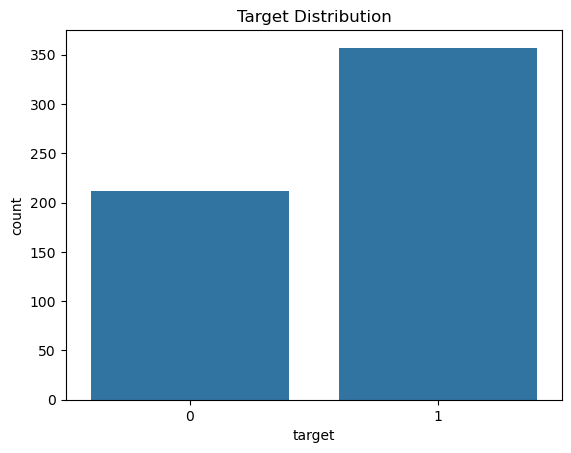

In [10]:
# Target Distribution
sns.countplot(x=y)
plt.title("Target Distribution")
plt.show()

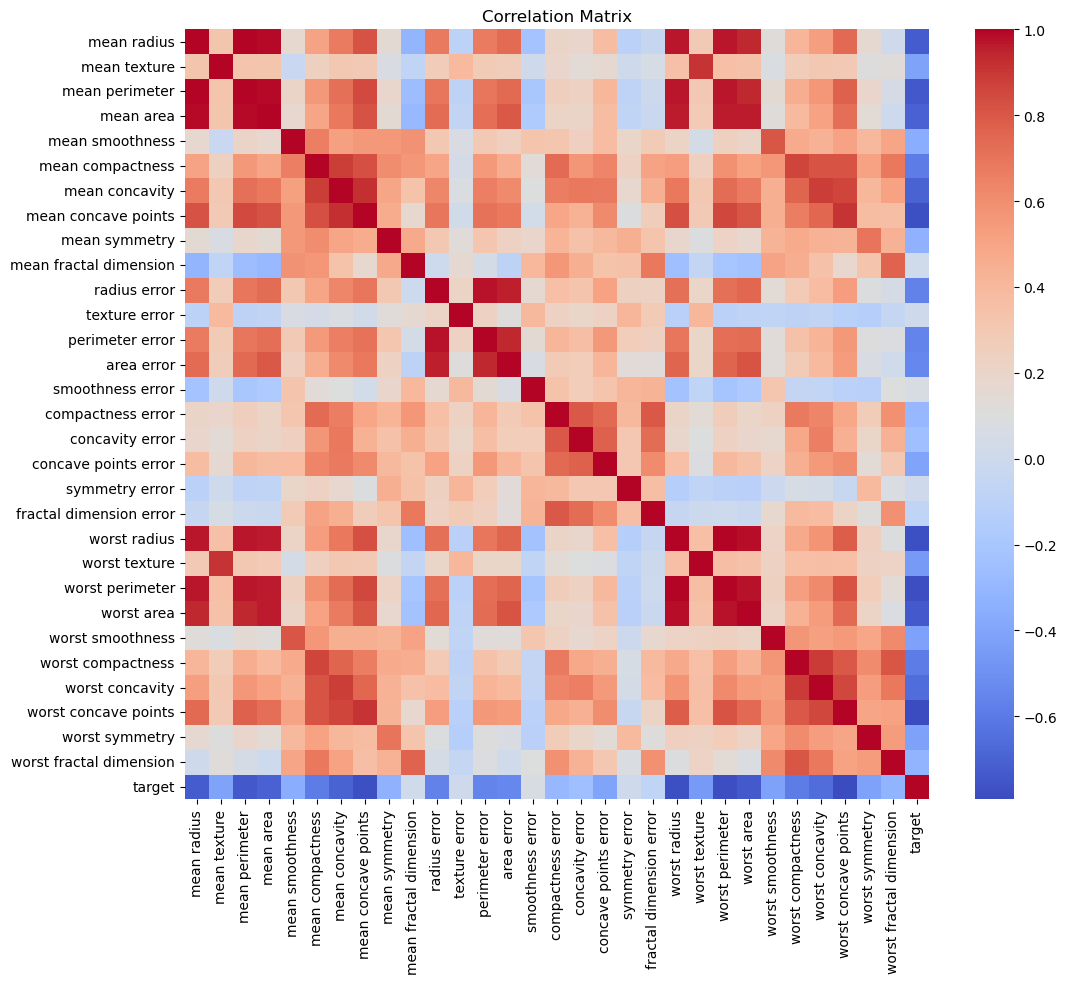

In [11]:
# Correlation Matrix
plt.figure(figsize=(12,10))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

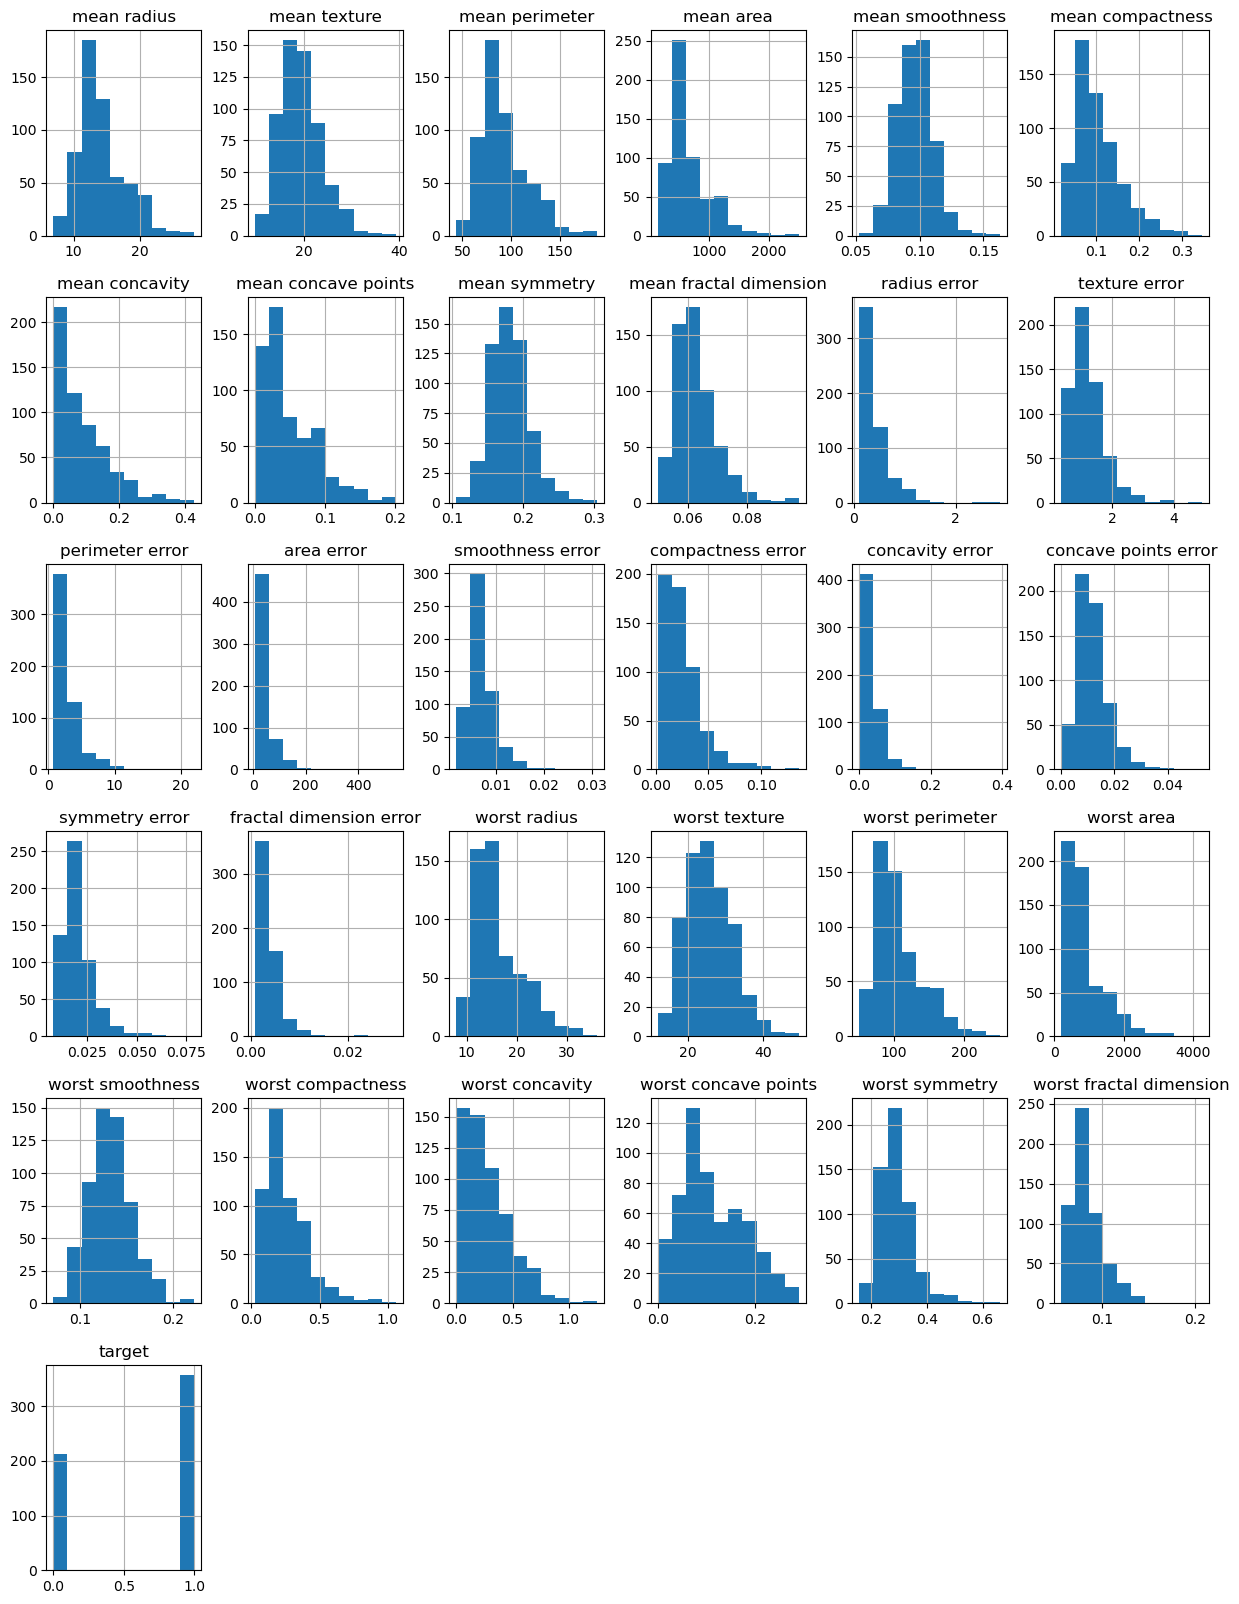

In [12]:
# Feature Distribution
df.hist(figsize=(15,20))
plt.show()

**Data Preprocessing**

In [13]:
numeric_features = X.columns

numeric_transformer = Pipeline(
    steps=[
        ("scaler", StandardScaler())
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features)
    ]
)

**Feature Engineering**

In [14]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2, include_bias=False)

X_poly = poly.fit_transform(X)

In [15]:
print("Original shape:", X.shape)
print("Polynomial shape:", X_poly.shape)

Original shape: (569, 30)
Polynomial shape: (569, 495)


**Train-Test Split**

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [17]:
print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

Training set shape: (455, 30)
Test set shape: (114, 30)


**Machine Learning Pipeline**

In [18]:
import os
os.environ["LOKY_MAX_CPU_COUNT"] = "4"

pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LGBMClassifier(random_state=42))
    ]
)

In [19]:
pipeline.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 285, number of negative: 170
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000237 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4545
[LightGBM] [Info] Number of data points in the train set: 455, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.626374 -> initscore=0.516691
[LightGBM] [Info] Start training from score 0.516691
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best 

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  Index(['mean radius', 'mean texture', 'mean perimeter', 'mean area',
       'mean smoothness', 'mean compactness', 'mean concavity',
       'mean concave points', 'mean symmetry', 'mean fractal dimension',
       'radius error', 'texture error', 'perimeter error', 'area error',
       'smoothness error', 'compactness error', 'concavity error',
       'concave points error', 'symmetry error', 'fractal dimension error',
       'worst radius', 'worst texture', 'worst perimeter', 'worst area',
       'worst smoothness', 'worst compactness', 'worst concavity',
       'worst concave points', 'worst symmetry', 'worst fractal dimension'],
      dtype='object'))])),
                ('model', LGBMClassifier(random_state=42))])

**Hyperparameter Tuning with GridSearchCV**

In [20]:
param_grid = {
    "model__n_estimators": [100, 200],
    "model__learning_rate": [0.01, 0.05, 0.1],
    "model__max_depth": [-1, 5, 10],
    "model__num_leaves": [31, 50, 100]
}

grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 285, number of negative: 170
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000244 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4545
[LightGBM] [Info] Number of data points in the train set: 455, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.626374 -> initscore=0.516691
[LightGBM] [Info] Start training from score 0.516691
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best 

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('scaler',
                                                                                          StandardScaler())]),
                                                                         Index(['mean radius', 'mean texture', 'mean perimeter', 'mean area',
       'mean smoothness', 'mean compactness', 'mean concavity',
       'mean concave points', 'mean symmetry', 'mean fractal dimension',
       'radius error', 'texture error', 'perim...
       'worst smoothness', 'worst compactness', 'worst concavity',
       'worst concave points', 'worst symmetry', 'worst fractal dimension'],
      dtype='object'))])),
                                       ('model',
                                        LGBMClassifier(random_state=42))]),
             n_jobs=-1,
             param_grid={'model__learning_rate': [0.01, 0.05, 0.1],
                         'model__max_depth': [-1, 5, 10],
                         'model__n_estimators': [100, 200],
                         'model__num_leaves': [31, 50, 100]},
             scoring='roc_auc')

In [21]:
# Best Parameters
print("Best Parameters:", grid_search.best_params_)
print("Best CV Score:", grid_search.best_score_)

Best Parameters: {'model__learning_rate': 0.1, 'model__max_depth': 10, 'model__n_estimators': 200, 'model__num_leaves': 31}
Best CV Score: 0.9909184726522188


**Model Evaluation**

In [22]:
best_model = grid_search.best_estimator_

y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:,1]

In [23]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc = roc_auc_score(y_test, y_prob)

In [24]:
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
print("ROC AUC:", roc)

Accuracy: 0.956140350877193
Precision: 0.9466666666666667
Recall: 0.9861111111111112
F1 Score: 0.9659863945578231
ROC AUC: 0.9874338624338624


In [25]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.90      0.94        42
           1       0.95      0.99      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



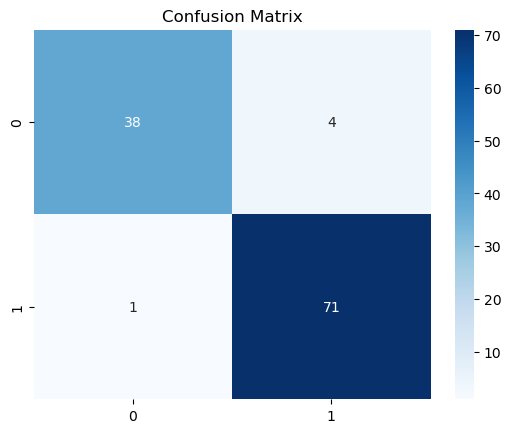

In [26]:
# Classification Report
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

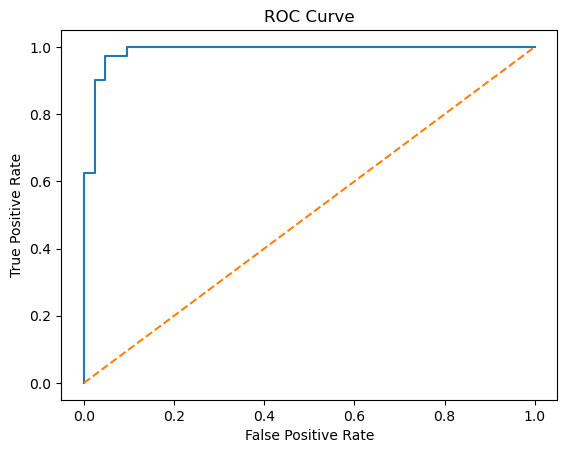

In [27]:
# ROC Curve

fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'--')
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

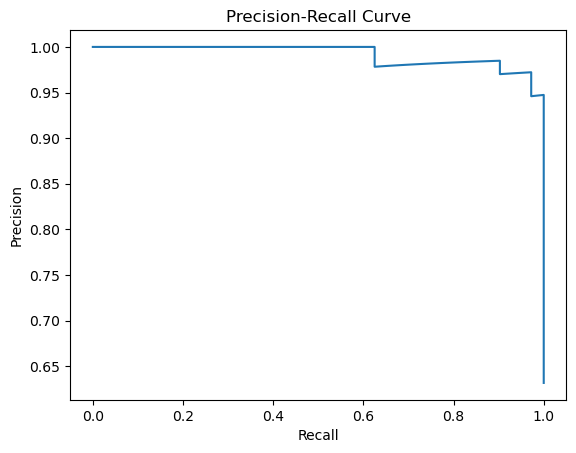

In [28]:
#  Precision–Recall Curve

precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_prob)

plt.plot(recall_vals, precision_vals)
plt.title("Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.show()


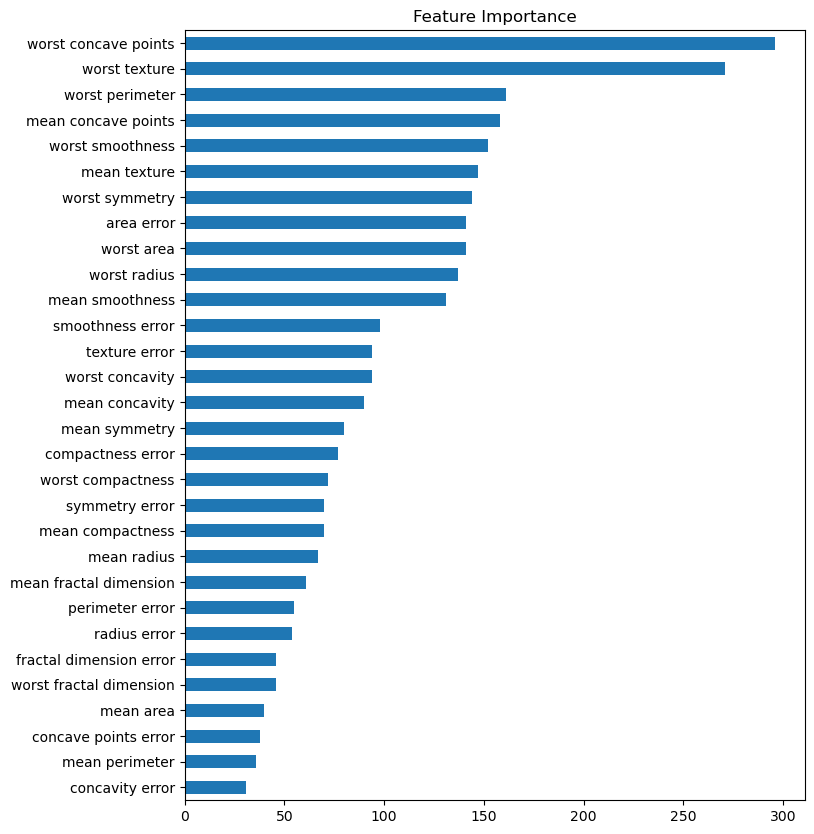

In [29]:
# Feature Importance

model = best_model.named_steps["model"]

importances = model.feature_importances_

feat_imp = pd.Series(importances, index=X.columns)

feat_imp.sort_values().plot(kind="barh", figsize=(8,10))
plt.title("Feature Importance")
plt.show()

[LightGBM] [Info] Number of positive: 4, number of negative: 41
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000112 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 498
[LightGBM] [Info] Number of data points in the train set: 45, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.088889 -> initscore=-2.327278
[LightGBM] [Info] Start training from score -2.327278
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gai

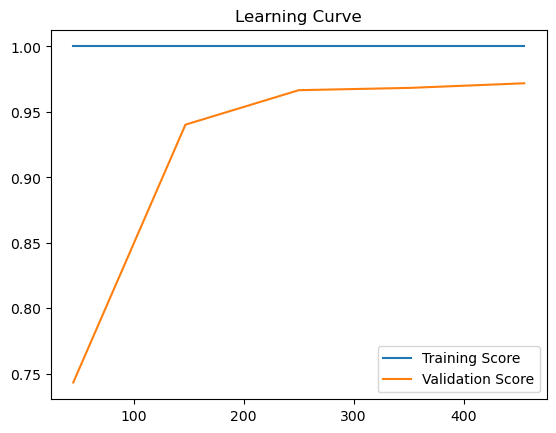

In [30]:
# Learning Curve

from sklearn.model_selection import learning_curve

train_sizes, train_scores, val_scores = learning_curve(
    best_model,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)

plt.plot(train_sizes, train_mean, label="Training Score")
plt.plot(train_sizes, val_mean, label="Validation Score")
plt.legend()
plt.title("Learning Curve")
plt.show()

**Feature Importance Visualization**

In [31]:
explainer = shap.TreeExplainer(model)

X_sample = X_test.sample(100, random_state=42)

shap_values = explainer.shap_values(X_sample)

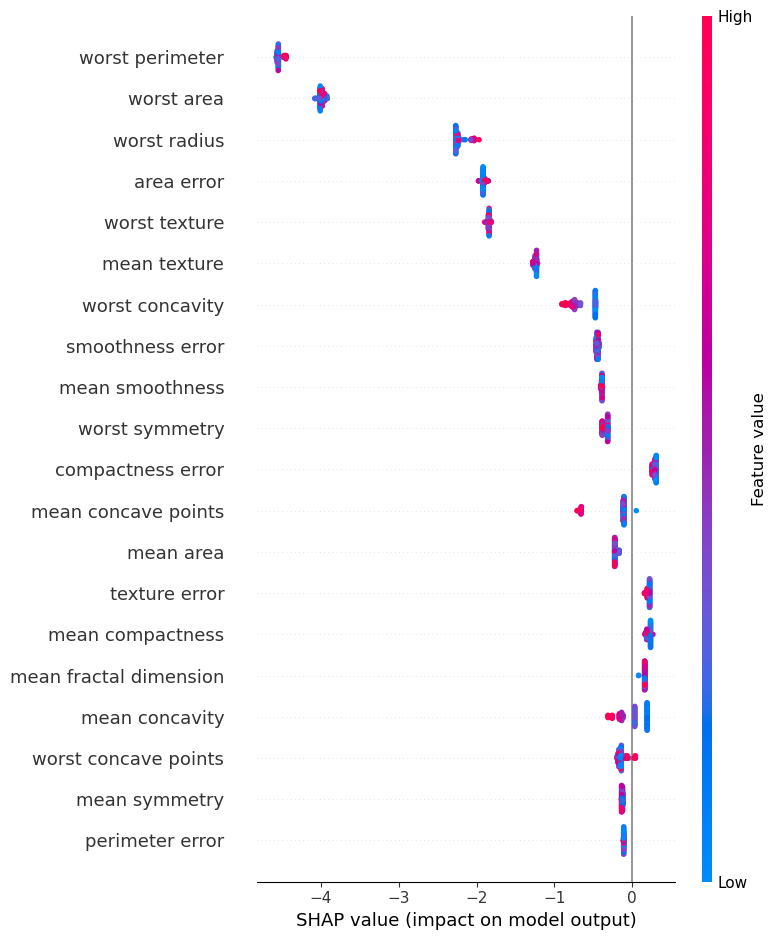

In [32]:
shap.summary_plot(shap_values, X_sample)

**permutation Importance**

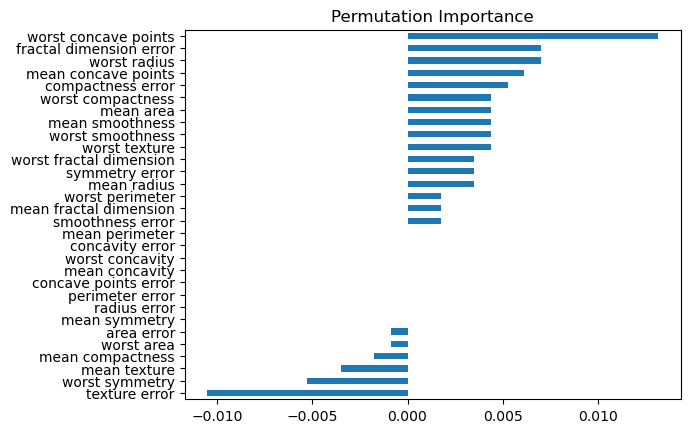

In [33]:
perm = permutation_importance(
    best_model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42
)

perm_importance = pd.Series(
    perm.importances_mean,
    index=X.columns
)

perm_importance.sort_values().plot.barh()
plt.title("Permutation Importance")
plt.show()

Important findings:

- Top features influencing predictions
-  AdaBoost improved classification accuracy
- Model generalizes well with cross-validation
- Limited overfitting observed

Possible improvements:

- Try **XGBoost / LightGBM / CatBoost**
- Use **feature selection**
- Tune hyperparameters more extensively


**Saving the Model**

In [34]:
joblib.dump(best_model, "lgbm_classifier_model.pkl")

['lgbm_classifier_model.pkl']